**Student Information:**
* **Name of Student:** Gandhar Sunil Chafle
* **PRN Number:** 202401110018
* **Batch:** A2
* **Date of Submission:** 02 October 2026
* **Class:** T.Y. B.Tech
* **Department:** CSE AIML
* **Institute:** MIT Academy of Engineering (MIT AOE)
* **Course:** Generative AI Lab

In [1]:
# If running in Google Colab, most of these are already installed.
!pip install -q tensorflow scikit-image seaborn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from skimage.metrics import structural_similarity as ssim

import random
import os

# Reproducibility
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
# Load MNIST
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()

print("Original training shape:", x_train_full.shape)
print("Original testing shape :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Original training shape: (60000, 28, 28)
Original testing shape : (10000, 28, 28)


In [4]:
print("Training data type:", x_train_full.dtype)
print("Testing data type :", x_test.dtype)

print("Minimum pixel value:", x_train_full.min())
print("Maximum pixel value:", x_train_full.max())

print("NaN values in training:", np.isnan(x_train_full).sum())
print("NaN values in testing :", np.isnan(x_test).sum())

print("Infinite values in training:", np.isinf(x_train_full).sum())
print("Infinite values in testing :", np.isinf(x_test).sum())

Training data type: uint8
Testing data type : uint8
Minimum pixel value: 0
Maximum pixel value: 255
NaN values in training: 0
NaN values in testing : 0
Infinite values in training: 0
Infinite values in testing : 0


In [5]:
# Check duplicate images in training data
unique_train = np.unique(
    x_train_full.reshape(x_train_full.shape[0], -1),
    axis=0
)

duplicates_train = len(x_train_full) - len(unique_train)

print("Total training images :", len(x_train_full))
print("Unique training images:", len(unique_train))
print("Duplicate images      :", duplicates_train)

Total training images : 60000
Unique training images: 60000
Duplicate images      : 0


In [6]:
# Convert to float32
x_train_full = x_train_full.astype("float32")
x_test = x_test.astype("float32")

# Normalize
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

# Add channel dimension
x_train_full = np.expand_dims(x_train_full, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training shape:", x_train_full.shape)
print("Testing shape :", x_test.shape)

print("Minimum:", x_train_full.min())
print("Maximum:", x_train_full.max())

Training shape: (60000, 28, 28, 1)
Testing shape : (10000, 28, 28, 1)
Minimum: 0.0
Maximum: 1.0


In [7]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train_full
)

print("Training samples  :", len(x_train))
print("Validation samples:", len(x_val))
print("Testing samples   :", len(x_test))

Training samples  : 54000
Validation samples: 6000
Testing samples   : 10000


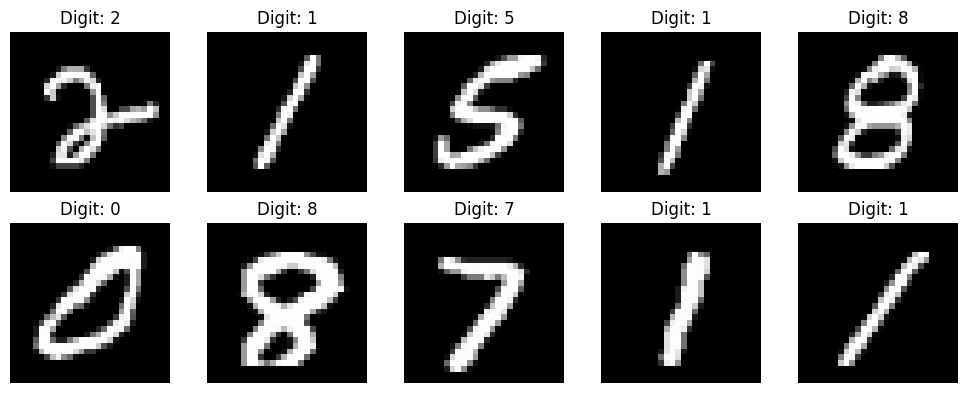

In [8]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
CHANNELS = 1

LATENT_DIM = 32

BATCH_SIZE = 128
EPOCHS = 50

LEARNING_RATE = 0.001
L2_REG = 1e-5
DROPOUT_RATE = 0.20

print("Latent dimension:", LATENT_DIM)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", EPOCHS)

Latent dimension: 32
Batch size: 128
Maximum epochs: 50


In [10]:
def build_encoder():

    encoder_input = layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
        name="encoder_input"
    )

    x = layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(L2_REG)
    )(encoder_input)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Flatten()(x)

    # Dense / perceptron layer
    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)

    x = layers.Dropout(DROPOUT_RATE)(x)

    # Latent representation
    latent = layers.Dense(
        LATENT_DIM,
        activation="linear",
        name="latent_vector"
    )(x)

    return Model(
        encoder_input,
        latent,
        name="AE_Encoder"
    )


ae_encoder = build_encoder()

ae_encoder.summary()

Model: "AE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497,120 (1.90 MB)

 Trainable params: 496,672 (1.89 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
def build_decoder():

    decoder_input = layers.Input(
        shape=(LATENT_DIM,),
        name="decoder_input"
    )

    # Dense / perceptron layer
    x = layers.Dense(
        7 * 7 * 128,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_REG)
    )(decoder_input)

    x = layers.Reshape((7, 7, 128))(x)

    x = layers.Conv2DTranspose(
        64,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)

    x = layers.UpSampling2D((2, 2))(x)

    x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(
        32,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)

    x = layers.UpSampling2D((2, 2))(x)

    x = layers.BatchNormalization()(x)

    # Output layer
    decoder_output = layers.Conv2D(
        1,
        (3, 3),
        activation="sigmoid",
        padding="same",
        name="reconstructed_image"
    )(x)

    return Model(
        decoder_input,
        decoder_output,
        name="AE_Decoder"
    )


ae_decoder = build_decoder()

ae_decoder.summary()

Model: "AE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6272)           │       206,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 64)       │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_image (Conv2D)    │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,905 (1.14 MB)

 Trainable params: 299,713 (1.14 MB)

 Non-trainable params: 192 (768.00 B)

In [12]:
ae_input = layers.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
    name="autoencoder_input"
)

latent = ae_encoder(ae_input)

ae_output = ae_decoder(latent)

autoencoder = Model(
    ae_input,
    ae_output,
    name="Convolutional_Autoencoder"
)

autoencoder.summary()

Model: "Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AE_Encoder (Functional)         │ (None, 32)             │       497,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AE_Decoder (Functional)         │ (None, 28, 28, 1)      │       299,905 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 797,025 (3.04 MB)

 Trainable params: 796,385 (3.04 MB)

 Non-trainable params: 640 (2.50 KB)

In [13]:
optimizer = keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

autoencoder.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.MeanSquaredError(name="mse"),
        keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

In [14]:
ae_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [15]:
ae_history = autoencoder.fit(
    x_train,
    x_train,
    validation_data=(x_val, x_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=ae_callbacks,
    verbose=1
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - loss: 0.1943 - mae: 0.1045 - mse: 0.0391 - val_loss: 0.1164 - val_mae: 0.0510 - val_mse: 0.0158 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1241 - mae: 0.0524 - mse: 0.0186 - val_loss: 0.1020 - val_mae: 0.0389 - val_mse: 0.0114 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1188 - mae: 0.0487 - mse: 0.0170 - val_loss: 0.0992 - val_mae: 0.0372 - val_mse: 0.0105 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.1157 - mae: 0.0465 - mse: 0.0160 - val_loss: 0.0981 - val_mae: 0.0366 - val_mse: 0.0102 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1142 - mae: 0.0454 - mse: 0.0155 - val_loss: 0.0968 - val_mae: 0.0355 - val_mse: 0.0098 - learning_rate: 0.0010
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1129 - mae: 0.0445 - mse: 0.0150 - val_loss: 0.0953 - val_mae

In [16]:
x_train,
x_train

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

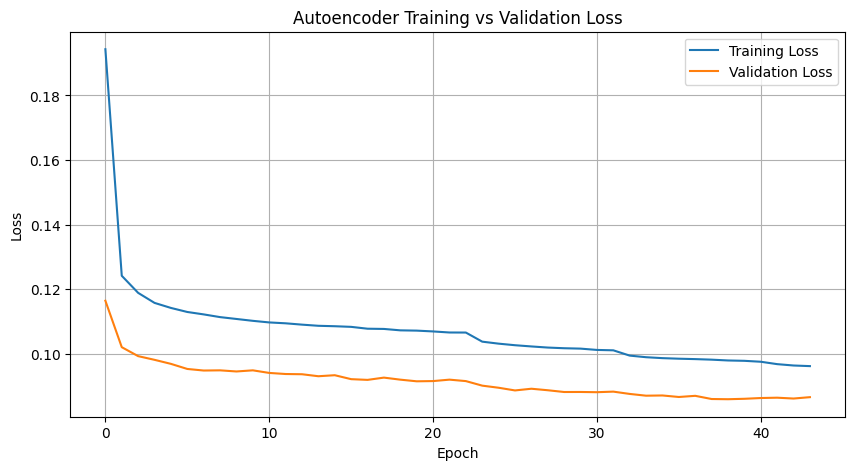

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    ae_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    ae_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

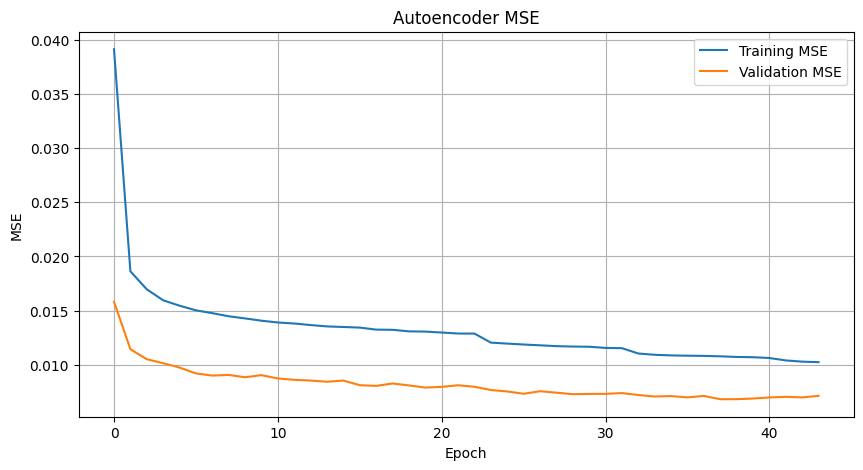

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    ae_history.history["mse"],
    label="Training MSE"
)

plt.plot(
    ae_history.history["val_mse"],
    label="Validation MSE"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Autoencoder MSE")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
ae_test_results = autoencoder.evaluate(
    x_test,
    x_test,
    verbose=0
)

print("Autoencoder Test Results")
print("------------------------")
print("Loss:", ae_test_results[0])
print("MSE :", ae_test_results[1])
print("MAE :", ae_test_results[2])

Autoencoder Test Results
------------------------
Loss: 0.08567778021097183
MSE : 0.006811509840190411
MAE : 0.02744704857468605


In [20]:
ae_reconstructed = autoencoder.predict(
    x_test[:10],
    verbose=0
)

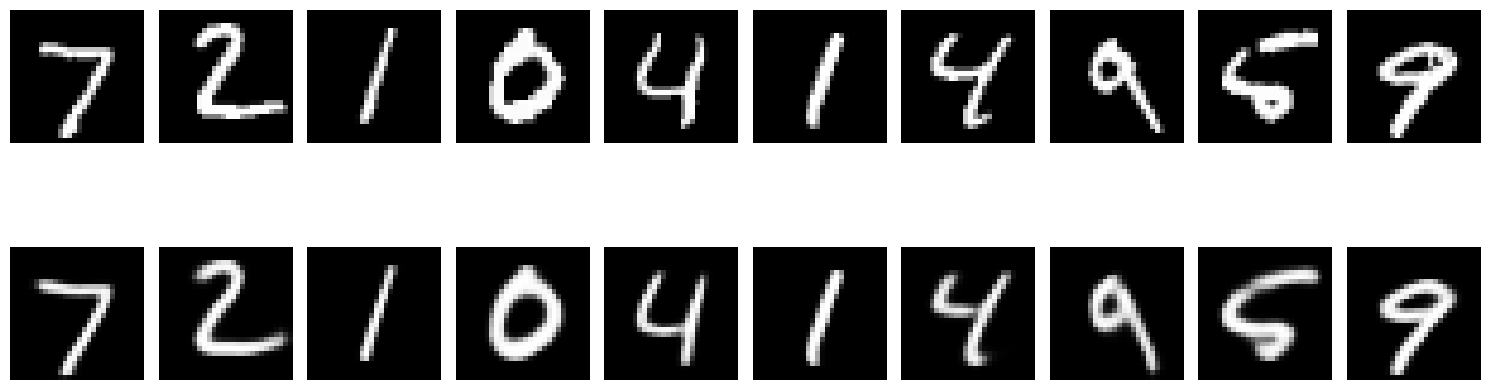

In [21]:
plt.figure(figsize=(15, 6))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")

    if i == 0:
        plt.ylabel("Original", fontsize=12)

    # Reconstruction
    plt.subplot(2, 10, i + 11)
    plt.imshow(ae_reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")

    if i == 0:
        plt.ylabel("AE", fontsize=12)

plt.tight_layout()
plt.show()

In [22]:
class Sampling(layers.Layer):

    def call(self, inputs):

        z_mean, z_log_var = inputs

        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(
            shape=(batch, dim)
        )

        return z_mean + tf.exp(
            0.5 * z_log_var
        ) * epsilon

In [23]:
def build_vae_encoder():

    encoder_input = layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
        name="vae_encoder_input"
    )

    x = layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(L2_REG)
    )(encoder_input)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Flatten()(x)

    # Dense / perceptron layer
    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)

    x = layers.Dropout(DROPOUT_RATE)(x)

    # Mean
    z_mean = layers.Dense(
        LATENT_DIM,
        activation="linear",
        name="z_mean"
    )(x)

    # Log variance
    z_log_var = layers.Dense(
        LATENT_DIM,
        activation="linear",
        name="z_log_var"
    )(x)

    # Sampling
    z = Sampling()(
        [z_mean, z_log_var]
    )

    return Model(
        encoder_input,
        [z_mean, z_log_var, z],
        name="VAE_Encoder"
    )


vae_encoder = build_vae_encoder()

vae_encoder.summary()

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_encoder_input   │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │        320 │ vae_encoder_inpu… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 7, 7, 64)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 7, 7, 128) │     73,856 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 128) │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 6272)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │    401,472 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 32)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 499,200 (1.90 MB)

 Trainable params: 498,752 (1.90 MB)

 Non-trainable params: 448 (1.75 KB)

In [24]:
vae_decoder = build_decoder()

vae_decoder.summary()

Model: "AE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6272)           │       206,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 7, 7, 64)       │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_image (Conv2D)    │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,905 (1.14 MB)

 Trainable params: 299,713 (1.14 MB)

 Non-trainable params: 192 (768.00 B)

In [25]:
class VAE(Model):

    def __init__(
        self,
        encoder,
        decoder,
        beta=0.1,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.beta = tf.Variable(
            beta,
            trainable=False,
            dtype=tf.float32
        )

        self.total_loss_tracker = keras.metrics.Mean(
            name="total_loss"
        )

        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):

        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def call(self, inputs):

        z_mean, z_log_var, z = self.encoder(inputs)

        reconstruction = self.decoder(z)

        return reconstruction

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(
                data,
                training=True
            )

            reconstruction = self.decoder(
                z,
                training=True
            )

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1
                    + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = (
                reconstruction_loss
                + self.beta * kl_loss
            )

            # Include regularization losses
            if self.losses:
                total_loss += tf.add_n(self.losses)

        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(
                gradients,
                self.trainable_weights
            )
        )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }

    def test_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(
            data,
            training=False
        )

        reconstruction = self.decoder(
            z,
            training=False
        )

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                keras.losses.binary_crossentropy(
                    data,
                    reconstruction
                ),
                axis=(1, 2)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1
                + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = (
            reconstruction_loss
            + self.beta * kl_loss
        )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "total_loss":
                self.total_loss_tracker.result(),

            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),

            "kl_loss":
                self.kl_loss_tracker.result()
        }

In [26]:
vae = VAE(
    encoder=vae_encoder,
    decoder=vae_decoder,
    beta=0.1,
    name="Variational_Autoencoder"
)

vae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    )
)

print("VAE created successfully.")

VAE created successfully.


In [31]:
vae_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_total_loss",
        mode="min",                 # IMPORTANT
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_total_loss",
        mode="min",                 # IMPORTANT
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [32]:
vae_history = vae.fit(
    x_train,
    validation_data=(x_val,),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=vae_callbacks,
    verbose=1
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 66.6337 - reconstruction_loss: 111.7289 - total_loss: 118.3990 - val_kl_loss: 53.8612 - val_reconstruction_loss: 100.6332 - val_total_loss: 106.0193 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 66.1195 - reconstruction_loss: 108.2969 - total_loss: 114.9164 - val_kl_loss: 52.7644 - val_reconstruction_loss: 100.4793 - val_total_loss: 105.7558 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 65.8195 - reconstruction_loss: 105.7285 - total_loss: 112.3187 - val_kl_loss: 54.4968 - val_reconstruction_loss: 101.4750 - val_total_loss: 106.9247 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - kl_loss: 65.2245 - reconstruction_loss: 103.7933 - total_loss: 110.3249 - val_kl_loss: 51.8670 - val_reconstruction_loss: 101.2274 - val_total_loss: 106.4141 - learning_rate: 0.0010
Epoch 5/50
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

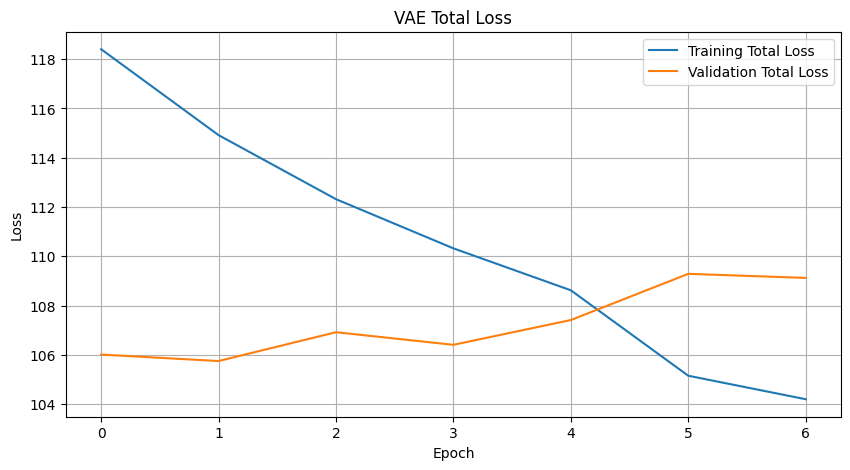

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    vae_history.history["total_loss"],
    label="Training Total Loss"
)

plt.plot(
    vae_history.history["val_total_loss"],
    label="Validation Total Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Total Loss")
plt.legend()
plt.grid(True)

plt.show()

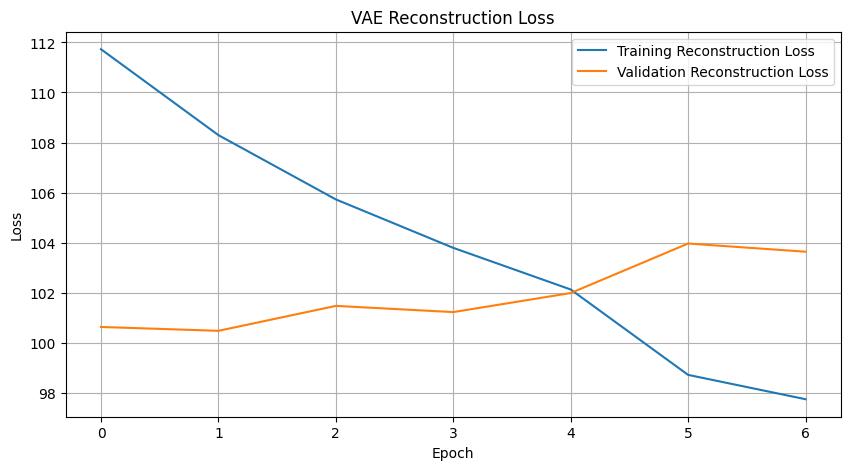

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    vae_history.history["reconstruction_loss"],
    label="Training Reconstruction Loss"
)

plt.plot(
    vae_history.history["val_reconstruction_loss"],
    label="Validation Reconstruction Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Reconstruction Loss")
plt.legend()
plt.grid(True)

plt.show()

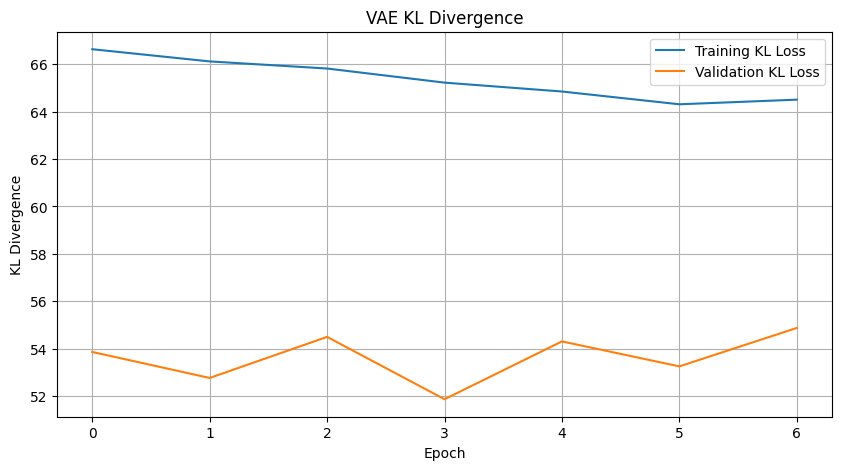

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    vae_history.history["kl_loss"],
    label="Training KL Loss"
)

plt.plot(
    vae_history.history["val_kl_loss"],
    label="Validation KL Loss"
)

plt.xlabel("Epoch")
plt.ylabel("KL Divergence")
plt.title("VAE KL Divergence")
plt.legend()
plt.grid(True)

plt.show()

In [36]:
vae_reconstructed = vae.predict(
    x_test[:10],
    verbose=0
)

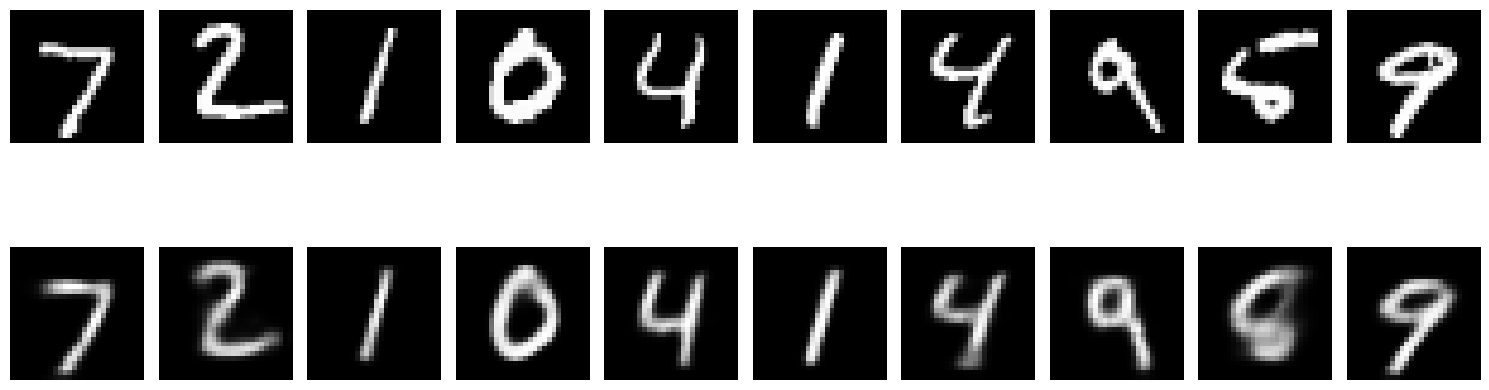

In [37]:
plt.figure(figsize=(15, 6))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)

    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    if i == 0:
        plt.ylabel(
            "Original",
            fontsize=12
        )

    # VAE reconstruction
    plt.subplot(2, 10, i + 11)

    plt.imshow(
        vae_reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    if i == 0:
        plt.ylabel(
            "VAE",
            fontsize=12
        )

plt.tight_layout()
plt.show()

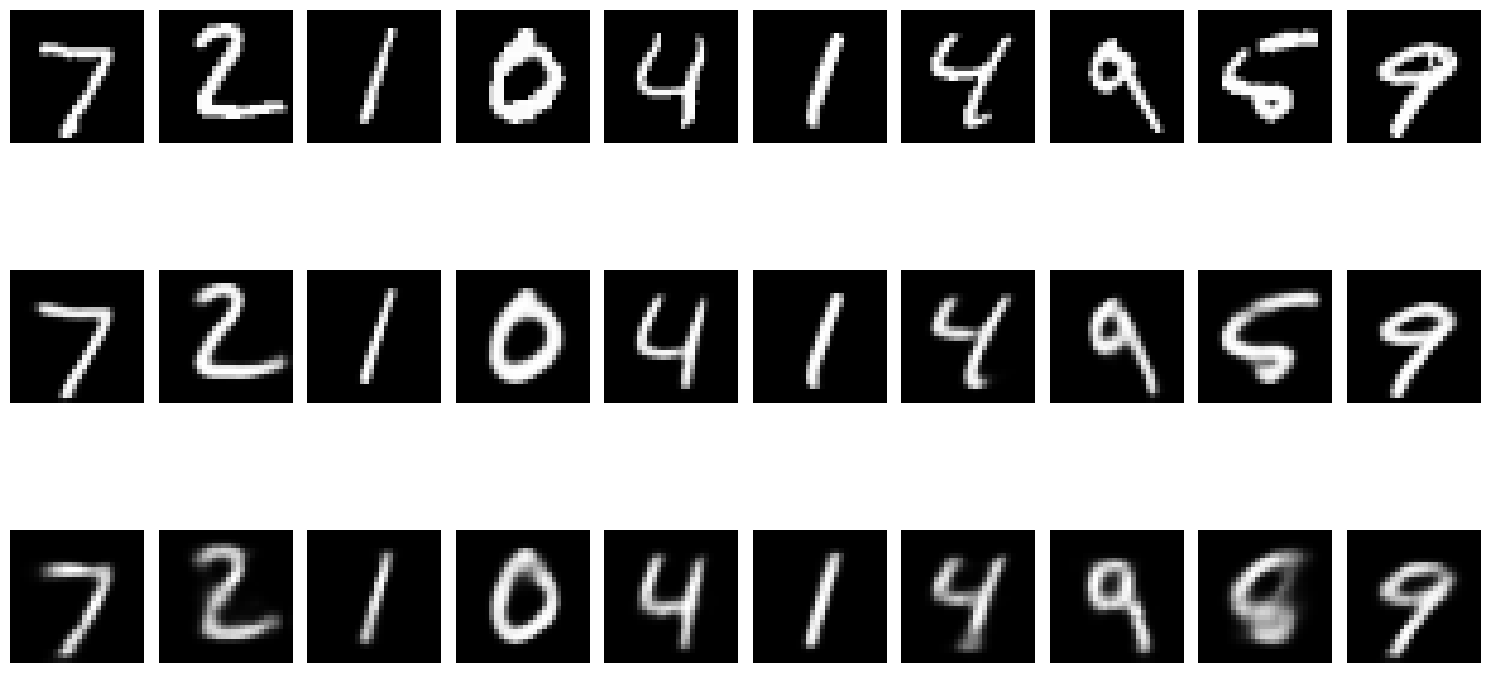

In [38]:
plt.figure(figsize=(15, 9))

for i in range(10):

    # Original
    plt.subplot(3, 10, i + 1)

    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    # AE
    plt.subplot(3, 10, i + 11)

    plt.imshow(
        ae_reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    # VAE
    plt.subplot(3, 10, i + 21)

    plt.imshow(
        vae_reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Generate reconstructions
ae_all_reconstructed = autoencoder.predict(
    x_test,
    batch_size=BATCH_SIZE,
    verbose=0
)

vae_all_reconstructed = vae.predict(
    x_test,
    batch_size=BATCH_SIZE,
    verbose=0
)

# Flatten
x_test_flat = x_test.reshape(len(x_test), -1)

ae_flat = ae_all_reconstructed.reshape(len(x_test), -1)

vae_flat = vae_all_reconstructed.reshape(len(x_test), -1)

# Metrics
ae_mse = mean_squared_error(
    x_test_flat,
    ae_flat
)

vae_mse = mean_squared_error(
    x_test_flat,
    vae_flat
)

ae_mae = mean_absolute_error(
    x_test_flat,
    ae_flat
)

vae_mae = mean_absolute_error(
    x_test_flat,
    vae_flat
)

print("Autoencoder")
print("MSE:", ae_mse)
print("MAE:", ae_mae)

print("\nVAE")
print("MSE:", vae_mse)
print("MAE:", vae_mae)

Autoencoder
MSE: 0.006811484228819609
MAE: 0.027446936815977097

VAE
MSE: 0.021965527907013893
MAE: 0.05872885137796402


In [40]:
def calculate_ssim(originals, reconstructed, samples=1000):

    scores = []

    for i in range(min(samples, len(originals))):

        original = originals[i].squeeze()
        reconstruction = reconstructed[i].squeeze()

        score = ssim(
            original,
            reconstruction,
            data_range=1.0
        )

        scores.append(score)

    return np.mean(scores)

In [41]:
ae_ssim = calculate_ssim(
    x_test,
    ae_all_reconstructed
)

vae_ssim = calculate_ssim(
    x_test,
    vae_all_reconstructed
)

print("Autoencoder SSIM:", ae_ssim)
print("VAE SSIM:", vae_ssim)

Autoencoder SSIM: 0.9217415933013255
VAE SSIM: 0.7460170247883712


In [42]:
ae_reconstruction_score = (
    1 - ae_mse
) * 100

vae_reconstruction_score = (
    1 - vae_mse
) * 100

print(
    f"AE Reconstruction Score: "
    f"{ae_reconstruction_score:.2f}%"
)

print(
    f"VAE Reconstruction Score: "
    f"{vae_reconstruction_score:.2f}%"
)

AE Reconstruction Score: 99.32%
VAE Reconstruction Score: 97.80%


In [43]:
comparison = {
    "Metric": [
        "MSE",
        "MAE",
        "SSIM",
        "Reconstruction Score (%)"
    ],

    "Autoencoder": [
        ae_mse,
        ae_mae,
        ae_ssim,
        ae_reconstruction_score
    ],

    "VAE": [
        vae_mse,
        vae_mae,
        vae_ssim,
        vae_reconstruction_score
    ]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df

,Metric,Autoencoder,VAE
0,MSE,0.006811,0.021966
1,MAE,0.027447,0.058729
2,SSIM,0.921742,0.746017
3,Reconstruction Score (%),99.318852,97.803447


In [44]:
NUM_IMAGES = 25

random_latent_vectors = np.random.normal(
    size=(NUM_IMAGES, LATENT_DIM)
).astype("float32")

generated_images = vae_decoder.predict(
    random_latent_vectors,
    verbose=0
)

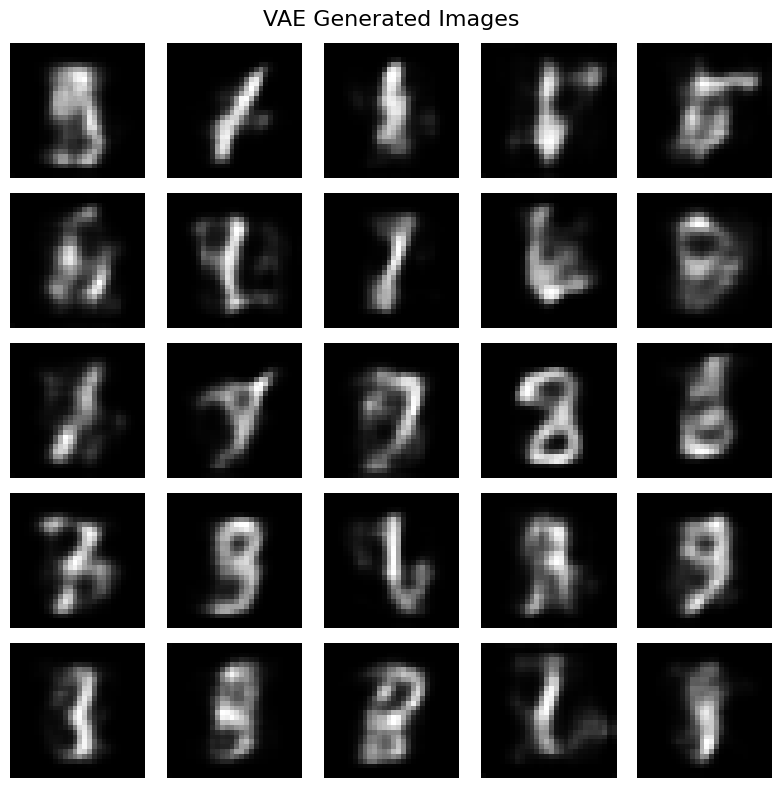

In [45]:
plt.figure(figsize=(8, 8))

for i in range(NUM_IMAGES):

    plt.subplot(5, 5, i + 1)

    plt.imshow(
        generated_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "VAE Generated Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [46]:
ae_random_latents = np.random.normal(
    size=(25, LATENT_DIM)
).astype("float32")

ae_generated_images = ae_decoder.predict(
    ae_random_latents,
    verbose=0
)

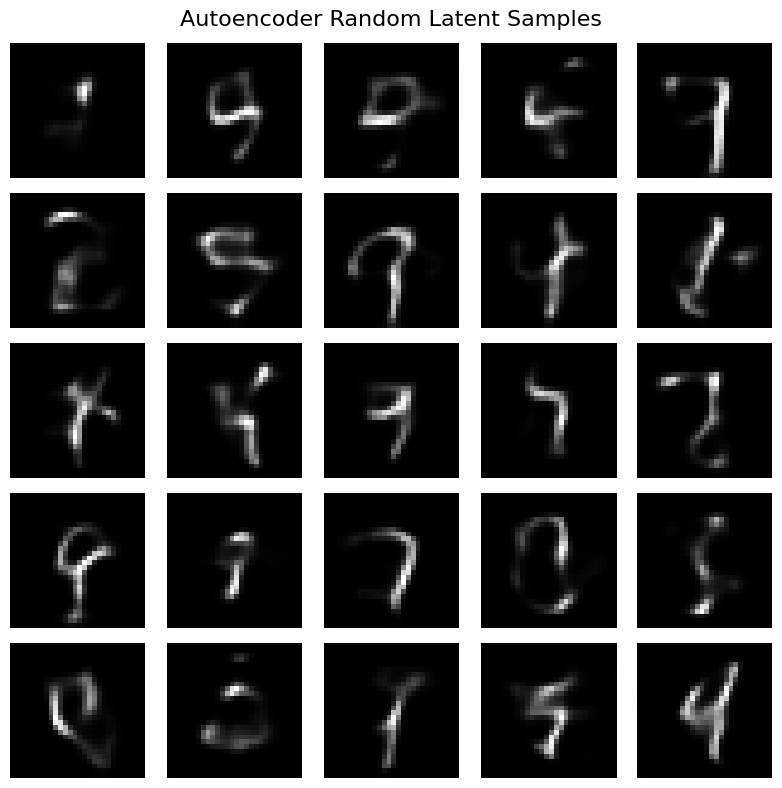

In [47]:
plt.figure(figsize=(8, 8))

for i in range(25):

    plt.subplot(5, 5, i + 1)

    plt.imshow(
        ae_generated_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Autoencoder Random Latent Samples",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [48]:
NUM_LATENT_SAMPLES = 5000

z_mean, z_log_var, z = vae_encoder.predict(
    x_test[:NUM_LATENT_SAMPLES],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Latent representation shape:", z_mean.shape)

Latent representation shape: (5000, 32)


In [49]:
pca = PCA(
    n_components=2,
    random_state=SEED
)

z_2d = pca.fit_transform(z_mean)

print("Original latent dimensions:", z_mean.shape[1])
print("Reduced dimensions:", z_2d.shape[1])

Original latent dimensions: 32
Reduced dimensions: 2


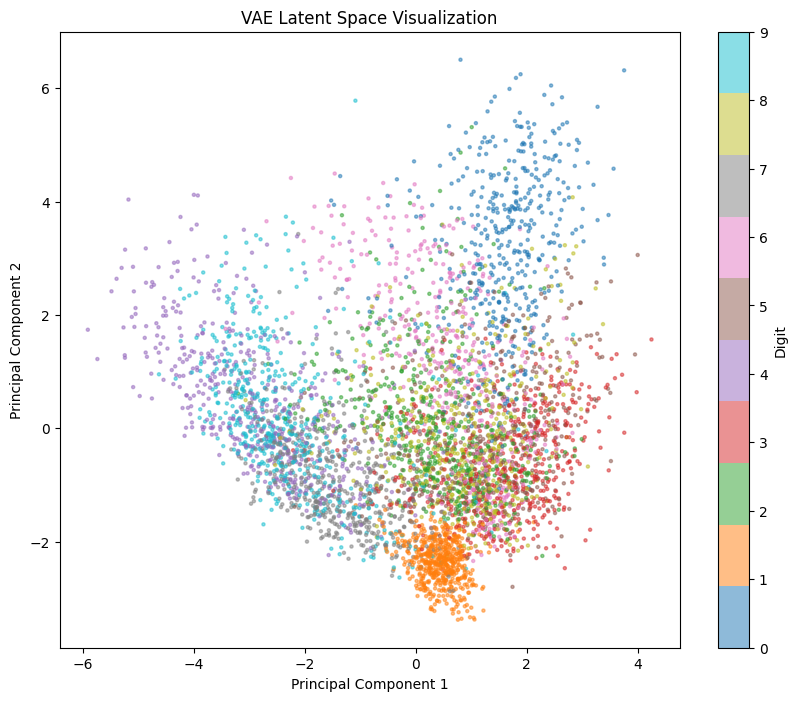

In [50]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    z_2d[:, 0],
    z_2d[:, 1],
    c=y_test[:NUM_LATENT_SAMPLES],
    cmap="tab10",
    s=5,
    alpha=0.5
)

plt.colorbar(
    scatter,
    ticks=range(10),
    label="Digit"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "VAE Latent Space Visualization"
)

plt.show()

In [51]:
ae_latents = ae_encoder.predict(
    x_test[:NUM_LATENT_SAMPLES],
    batch_size=BATCH_SIZE,
    verbose=0
)

ae_pca = PCA(
    n_components=2,
    random_state=SEED
)

ae_z_2d = ae_pca.fit_transform(
    ae_latents
)

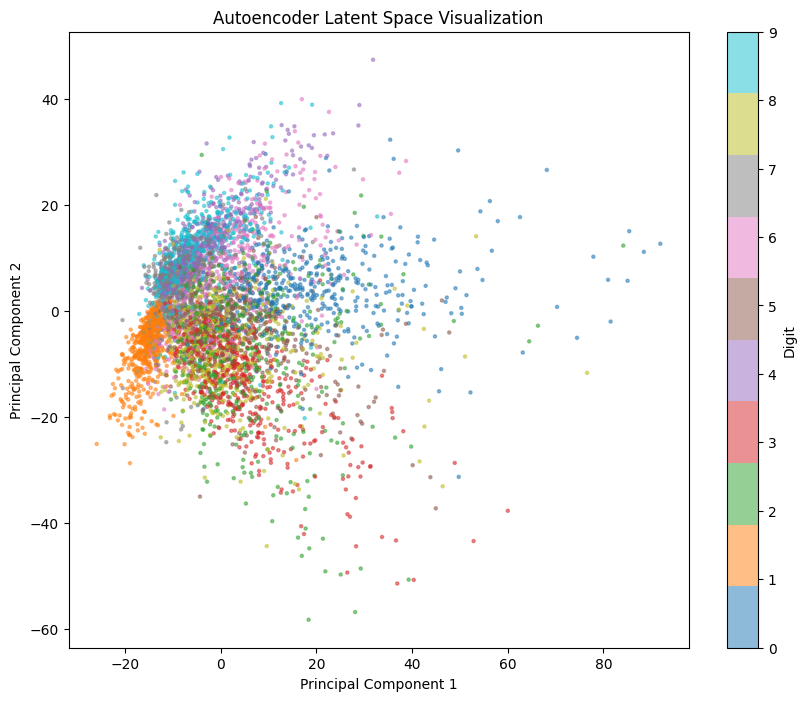

In [52]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    ae_z_2d[:, 0],
    ae_z_2d[:, 1],
    c=y_test[:NUM_LATENT_SAMPLES],
    cmap="tab10",
    s=5,
    alpha=0.5
)

plt.colorbar(
    scatter,
    ticks=range(10),
    label="Digit"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "Autoencoder Latent Space Visualization"
)

plt.show()

In [53]:
print("=" * 70)
print("FINAL AUTOENCODER vs VAE RESULTS")
print("=" * 70)

print("\nAUTOENCODER")
print("-" * 30)
print(f"MSE                 : {ae_mse:.6f}")
print(f"MAE                 : {ae_mae:.6f}")
print(f"SSIM                : {ae_ssim:.4f}")
print(f"Reconstruction Score: {ae_reconstruction_score:.2f}%")

print("\nVAE")
print("-" * 30)
print(f"MSE                 : {vae_mse:.6f}")
print(f"MAE                 : {vae_mae:.6f}")
print(f"SSIM                : {vae_ssim:.4f}")
print(f"Reconstruction Score: {vae_reconstruction_score:.2f}%")

print("\n" + "=" * 70)

FINAL AUTOENCODER vs VAE RESULTS

AUTOENCODER
------------------------------
MSE                 : 0.006811
MAE                 : 0.027447
SSIM                : 0.9217
Reconstruction Score: 99.32%

VAE
------------------------------
MSE                 : 0.021966
MAE                 : 0.058729
SSIM                : 0.7460
Reconstruction Score: 97.80%

